> <h1 style="color: #b30b0b;"> Superstore Data Analysis Project : </h1>
>
>Hello, this is a dataset related to a **Multinational Retail Company** that needs an automated analytical solution to monitor sales, profitability, customer behavior, and operational performance...
>
>And The objective of this notebook is to perform comprehensive **data cleaning, feature engineering, and exploratory data analysis (EDA) to answer all of these *Questions* and more :-**<br>
>
>1.Which product category drives the most revenue & Profability?<br>
>2.What are the top 5 best-selling and top 5 least profitable sub-categories? <br>
>3.Which region generated the highest total sales?<br>
>4.What are the top 10 most profitable states?<br>
>5.What are the strongest factors effect on Profit and Sales? <br>
>6.Which category has the highest number of returned orders?<br>
>7.What is the fastest ship mode in delivery?<br>
>8.How have total sales trended over time?<br>
>9.What is the Most Popular Ship Mode?<br>
<br>
<br>



## **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
logger = logging.getLogger('superstore')

In [6]:
logging.basicConfig(filename='logfile1.log',
                    level=logging.INFO,
                    format='%(asctime)s:%(levelname)s:%(message)s')

In [7]:
def load_data(file_path):
    
    try:
        df = pd.read_excel(file_path,sheet_name=None)
        logging.info(f'Successfully Loaded {file_path}')
        print(f"Loaded {file_path}")
        return (
            df['Orders'],
            df['People'],
            df['Returns'],
        )
        
    except FileNotFoundError:
        logging.error(f'{file_path} missing')
        print(f'{file_path} missing')
        return None,None,None
    except Exception as e:
        logging.error(str(e))
        print(e)
        return None,None,None
    
file_path = r'C:\Users\uo\DataAnalysis_Projects\Python_Projects\Depi_miniProject\superstore_notebook\Datesets\Superstore 2019-rawdata.xls'
Orders, People, Returns = load_data(file_path)

Loaded C:\Users\uo\DataAnalysis_Projects\Python_Projects\Depi_miniProject\superstore_notebook\Datesets\Superstore 2019-rawdata.xls


### **-Orders Sheet**

In [8]:
#display the first 5 rows of the Orders DataFrame
Orders.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [9]:
#display the last 5 rows of the Orders DataFrame
Orders.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2019-119914,2019-05-04,2019-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [10]:
print("--- Rows And Columns Counts : Orders Sheet ---")
Orders.shape

--- Rows And Columns Counts : Orders Sheet ---


(9994, 21)

In [11]:
print("--- The Statistical Summary of numerical columns : Orders Sheet ---")
Orders.describe()

--- The Statistical Summary of numerical columns : Orders Sheet ---


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


In [12]:
print("--- Statistical Summary Of Categorical Data : Orders Sheet ---")
Orders.describe(include="str")

--- Statistical Summary Of Categorical Data : Orders Sheet ---


,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2019-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [13]:
# Calculate the date range (first and last order/shipment dates) to understand the dataset's timeframe
print('Data range :')
print('First Order Date :',Orders['Order Date'].min().date())
print('First Ship Date',Orders['Ship Date'].min().date())
print('---')
print('Last Order Date :',Orders['Order Date'].max().date())
print('Last Ship Date',Orders['Ship Date'].max().date())


Data range :
First Order Date : 2016-01-03
First Ship Date 2016-01-07
---
Last Order Date : 2019-12-30
Last Ship Date 2020-01-05


In [14]:
print("--- Orders Sheet Information --- \n")
Orders.info()

--- Orders Sheet Information --- 

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   

In [15]:
print("--- Orders Sheet Data Types --- \n")
Orders.dtypes

--- Orders Sheet Data Types --- 



Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [ ]:
print("--- Uniqe Values Counts: Orders Sheet ---\n")
for f in Orders.columns:
    r=Orders[f].nunique()
    print(f'{f} : {r}')

--- Uniqe Values Counts: Orders Sheet ---

Row ID : 9994
Order ID : 5009
Order Date : 1236
Ship Date : 1334
Ship Mode : 4
Customer ID : 793
Customer Name : 793
Segment : 3
Country/Region : 1
City : 531
State : 49
Postal Code : 630
Region : 4
Product ID : 1862
Category : 3
Sub-Category : 17
Product Name : 1850
Sales : 6144
Quantity : 14
Discount : 12
Profit : 7545


In [17]:
#check values names in the 'City' column of the 'Orders' DataFrame
Orders['City'].unique()

<ArrowStringArray>
[        'Henderson',       'Los Angeles',   'Fort Lauderdale',
           'Concord',           'Seattle',        'Fort Worth',
           'Madison',       'West Jordan',     'San Francisco',
           'Fremont',
 ...
        'Hagerstown',       'East Orange', 'Arlington Heights',
            'Oswego',       'Coon Rapids',      'San Clemente',
   'San Luis Obispo',        'Springdale',              'Lodi',
             'Mason']
Length: 531, dtype: str

In [18]:
#check values names in the 'State' column of the 'Orders' DataFrame
Orders['State'].unique()

<ArrowStringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',           'Washington',                'Texas',
            'Wisconsin',                 'Utah',             'Nebraska',
         'Pennsylvania',             'Illinois',            'Minnesota',
             'Michigan',             'Delaware',              'Indiana',
             'New York',              'Arizona',             'Virginia',
            'Tennessee',              'Alabama',       'South Carolina',
               'Oregon',             'Colorado',                 'Iowa',
                 'Ohio',             'Missouri',             'Oklahoma',
           'New Mexico',            'Louisiana',          'Connecticut',
           'New Jersey',        'Massachusetts',              'Georgia',
               'Nevada',         'Rhode Island',          'Mississippi',
             'Arkansas',              'Montana',        'New Hampshire',
             'Maryland', 'Distri

In [19]:
#check values names in the 'Category' column of the 'Orders' DataFrame
Orders['Category'].unique()

<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [20]:
#check values names in the 'Sub Category' column of the 'Orders' DataFrame
Orders['Sub-Category'].unique()

<ArrowStringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

In [21]:
print("missing values for each column:")
Orders.isnull().sum()


missing values for each column:


Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [22]:
print ('missing values percentage for each column:')
missing_pct=(Orders.isnull().mean().mul(100).round(2).sort_values(ascending=False))
missing_pct 

missing values percentage for each column:


Postal Code       0.11
Order ID          0.00
Order Date        0.00
Ship Date         0.00
Row ID            0.00
Ship Mode         0.00
Customer ID       0.00
Segment           0.00
Customer Name     0.00
Country/Region    0.00
City              0.00
State             0.00
Region            0.00
Product ID        0.00
Category          0.00
Sub-Category      0.00
Product Name      0.00
Sales             0.00
Quantity          0.00
Discount          0.00
Profit            0.00
dtype: float64

In [23]:
#check is there any correlation between columns
print ('Correlation Matrix : ')
corr_cols = ['Sales','Quantity', 'Discount', 'Profit']
correlation_result = Orders[corr_cols].corr()
correlation_result.round(3)

Correlation Matrix : 


,Sales,Quantity,Discount,Profit
Sales,1.000,0.201,-0.028,0.479
Quantity,0.201,1.000,0.009,0.066
Discount,-0.028,0.009,1.000,-0.219
Profit,0.479,0.066,-0.219,1.000


> <h1 style="color: #d4cdcd; font-size: 20px; margin: 0;"> Key Insight :- </h1>
>
> **Sales vs. Profit:** Shows a weak positive correlation = 0.47 <br>
> **Sales vs. Discount:** Discount does not significantly affect Sales = -0.028 
><br>
><br>

> <h1 style="color: #ff1717; font-size: 22px; margin: 0;"> Orders Sheet Summary :- </h1>
>
>-The Orders dataset has **9,994 rows and 21 columns from 2016 to 2019. It includes 5,009 orders across 793 unique customers, with an average delivery time of 4 days**.
><br>
>-There are **missing values** in (Postal Code column).
><br>
>-There is a very **weak relationship** between discount and sales.
><br>
><br>

### **-People Sheet**

In [24]:
#display the first rows of the People DataFrame
People.head()

,Person,Region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


In [25]:
#display the last 5 rows of the People DataFrame
People.tail()

,Person,Region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


In [26]:
print("--- People Sheet info ---\n")
People.info()

--- People Sheet info ---

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Person  4 non-null      str  
 1   Region  4 non-null      str  
dtypes: str(2)
memory usage: 271.0 bytes


In [27]:
print("--- Statistical Summary: People Sheet  ---\n")
People.describe()

--- Statistical Summary: People Sheet  ---



,Person,Region
count,4,4
unique,4,4
top,Anna Andreadi,West
freq,1,1


In [28]:
print("--- Uniqe Values Counts: People Sheet --- \n")
for f in People.columns:
    r=People[f].nunique()
    print(f'{f} : {r}')
    

--- Uniqe Values Counts: People Sheet --- 

Person : 4
Region : 4


In [29]:
print("--- People Sheet Data types ---")
People.dtypes

--- People Sheet Data types ---


Person    str
Region    str
dtype: object

> <h1 style="color: #ff1717; font-size: 20px; margin: 0;"> People Sheet Summary :- </h1>
> The People sheet contains 4 rows,assigning one regional manager per unique region 
><br>
><br>

### **-Returns Sheet**

In [30]:
#display the first rows of the Returns DataFrame
Returns.head(10)

,Returned,Order ID
0,Yes,CA-2016-100762
1,Yes,CA-2016-100762
2,Yes,CA-2016-100762
3,Yes,CA-2016-100762
4,Yes,CA-2016-100867
5,Yes,CA-2016-102652
6,Yes,CA-2016-102652
7,Yes,CA-2016-102652
8,Yes,CA-2016-102652
9,Yes,CA-2016-103373


> <span style="color: #b6a5a5; font-size: 20px;">Note :- </span><span style="color: #fff2f2; font-size: 18px;">The top rows show some duplicate values...</span>

In [31]:
#display the first 5 rows of the Returns DataFrame
Returns.tail()

,Returned,Order ID
795,Yes,US-2019-147886
796,Yes,US-2019-147998
797,Yes,US-2019-151127
798,Yes,US-2019-155999
799,Yes,US-2019-155999


In [32]:
print("--- Returns Sheet information: ---\n")
Returns.info()

--- Returns Sheet information: ---

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Returned  800 non-null    str  
 1   Order ID  800 non-null    str  
dtypes: str(2)
memory usage: 25.9 KB


In [33]:
print('--- Summary Statistics: Returns Sheet ---')
Returns.describe()

--- Summary Statistics: Returns Sheet ---


,Returned,Order ID
count,800,800
unique,1,296
top,Yes,CA-2019-100111
freq,800,14


In [34]:
print("--- Unique Values Count: Returns Sheet ---\n")
for f in Returns.columns:
    r=Returns[f].nunique()
    print (f' {f} : {r} ')  



--- Unique Values Count: Returns Sheet ---

 Returned : 1 
 Order ID : 296 


> <h1 style="color: #ff1717; font-size: 21px; margin: 0;"> Returns Sheet Summary :- </h1>
>The Returns sheet has 800 rows and 2 columns: Order ID and Returned. Of the Order ID values, 296 are unique and the rest are duplicates. 
><br>
><br>

## **Data Cleaning**

### Rename Columns

In [35]:
#Change the column names 'Sub-Category' and 'Country/Region' in the Orders DataFrame
Orders=Orders.rename(columns={'Sub-Category':'Sub Category','Country/Region':'Country'})
Orders.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


### Change Data Types

In [36]:
#convert Postal Code and Row ID data types to string type
Orders['Postal Code'] = Orders['Postal Code'].astype('str')
Orders['Row ID'] = Orders['Row ID'].astype('str')
Orders.dtypes

Row ID                      str
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code                 str
Region                      str
Product ID                  str
Category                    str
Sub Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

### Fill The Nulls With Values 

In [37]:
#display the missing poatsl code that belong to cityand state
Orders.loc[Orders['Postal Code'].isnull(),['State','City','Postal Code']]

,State,City,Postal Code
2234,Vermont,Burlington,NaN
5274,Vermont,Burlington,NaN
8798,Vermont,Burlington,NaN
9146,Vermont,Burlington,NaN
9147,Vermont,Burlington,NaN
9148,Vermont,Burlington,NaN
9386,Vermont,Burlington,NaN
9387,Vermont,Burlington,NaN
9388,Vermont,Burlington,NaN
9389,Vermont,Burlington,NaN


> **Key Insight :-** <br>
><br>
> All missing postal codes are for **Burlington, Vermont**. After searching, Burlington has three Postal codes (05401, 05402, 05408), so I used the main one **05401**.
><br>
><br>

In [38]:
# replace the nulls with the Burlington main postal code
Orders['Postal Code'] = Orders['Postal Code'].fillna('05401')
Orders.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Handling With The Outliers

In [39]:
#check if there outliers in each sheet
def handling_with_outliers(df, columns=None):
    try:
        columns = columns or ["Sales", "Discount", "Profit"]
        Orders = df.copy()
        print('Outliers Detection:')

        for col in columns:
            if col in Orders.columns:
                Q1 = Orders[col].quantile(0.25)
                Q3 = Orders[col].quantile(0.75)
                IQR = Q3 - Q1

                lower_fence = Q1 - 1.5 * IQR
                upper_fence = Q3 + 1.5 * IQR
        
                outliers = (Orders[col] < lower_fence) | (Orders[col] > upper_fence)
                outlier_count = outliers.sum()
                print(
                    f"There are {outlier_count} outliers in {col} column"
                )       
        return Orders

    except Exception as e:
        print(f"Error while handling outliers: {e}")
        return df
    
Orders = handling_with_outliers(Orders, columns=["Sales", "Discount", "Profit"])

Outliers Detection:
There are 1167 outliers in Sales column
There are 856 outliers in Discount column
There are 1881 outliers in Profit column


In [40]:
# Check the outlier records to see if these extreme values are mistakes or natural high-value sales
Q1 = Orders['Sales'].quantile(0.25)
Q3 = Orders['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_fence= Q1 - 1.5 * IQR
upper_fence= Q3 + 1.5 * IQR
outliers=Orders[(Orders['Sales'] < lower_fence) | (Orders['Sales'] > upper_fence)]
outliers[['Sales','Category','Sub Category']].head(30)

,Sales,Category,Sub Category
1,731.9400,Furniture,Chairs
3,957.5775,Furniture,Tables
7,907.1520,Technology,Phones
10,1706.1840,Furniture,Tables
11,911.4240,Technology,Phones
16,665.8800,Office Supplies,Storage
24,1044.6300,Furniture,Tables
27,3083.4300,Furniture,Bookcases
35,1097.5440,Technology,Phones
38,532.3992,Furniture,Bookcases


> **Note**
><br>
>Most of the highest sales are in Furniture and Technology like Machines and Phones , Because these products are expensive, these high values are normal sales not data errors.
><br>
><br>

### Handling With The Duplicates

In [41]:
class DataCleaner:
    def __init__(self,df:pd.DataFrame):
        self.df=df.copy()
        self.report = {}

    def remove_duplicates(self):    
        try:
            before = len(self.df)
            self.df = self.df.drop_duplicates()
            self.report['Duplicates Found:']= before - len(self.df)
        except Exception as e:
            logger.error(f"remove_duplicates failed: {e}")
        return self    
    
    def get(self) -> pd.DataFrame:
        return self.df
    
cleaner = DataCleaner(Returns)
cleaner.remove_duplicates()
Returns = cleaner.df

print("Cleaning report:\n")
for k, v in cleaner.report.items():
    print(f'{k} {v}')
    #check the duplicates Removed
    print(f'Duplicates after cleaning: {Returns.duplicated().sum()}')
    
Returns = cleaner.get()

Cleaning report:

Duplicates Found: 504
Duplicates after cleaning: 0


#### **Merging The Sheets Together**

In [42]:
try:
    orders_people_merged = pd.merge(Orders,People, on='Region',how='left')
except Exception as e:
    print(f"Error while merging People: {e}")

try:
    df = pd.merge(orders_people_merged,Returns, on='Order ID',how='left')
except Exception as e:
    print(f'Error while merging Returns: {e}')
finally :
    print('Merged Successfully')

Merged Successfully


### Replace the null values with No in Returned column

In [43]:
df['Returned'] = df['Returned'].fillna('No')
print(df['Returned'].unique())


<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [44]:
#Check The Data Types ,Nulls and Unique values in The New Dataframe
print('--- Number of rows and columns in df DataFrame :',df.shape,'--- \n')
df_overview = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Counts': df.isnull().sum(),
    'Unique Values': df.nunique()
})
print(df_overview)

--- Number of rows and columns in df DataFrame : (9994, 23) --- 

                    Data Type  Null Counts  Unique Values
Row ID                    str            0           9994
Order ID                  str            0           5009
Order Date     datetime64[us]            0           1236
Ship Date      datetime64[us]            0           1334
Ship Mode                 str            0              4
Customer ID               str            0            793
Customer Name             str            0            793
Segment                   str            0              3
Country                   str            0              1
City                      str            0            531
State                     str            0             49
Postal Code               str            0            631
Region                    str            0              4
Product ID                str            0           1862
Category                  str            0              3
Sub Ca

## **Data Manipulation**

In [45]:
#Create Discount Percentage Column to show the discount in Perc. Format
df['Discount_Percentage'] =df['Discount'] * 100
df['Discount_Percentage']=df['Discount_Percentage'].astype(int)
df['Discount_Percentage'].unique()

array([ 0, 45, 20, 80, 30, 50, 70, 60, 32, 10, 40, 15])

In [46]:
# Calculate >>> Total Cost = Sales - Profit
df['Total Cost'] = df['Sales'] - df['Profit']
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub Category,Product Name,Sales,Quantity,Discount,Profit,Person,Returned,Discount_Percentage,Total Cost
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,Cassandra Brandow,No,0,220.0464
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,Cassandra Brandow,No,0,512.3580
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,Anna Andreadi,No,0,7.7486


In [47]:
# Calculate >>> Unit Price = Sales / Quantity
df['Unit Price'] = df['Sales'] / df['Quantity']
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Person,Returned,Discount_Percentage,Total Cost,Unit Price
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,Cassandra Brandow,No,0,220.0464,130.98
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,Cassandra Brandow,No,0,512.3580,243.98
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,Anna Andreadi,No,0,7.7486,7.31


In [48]:
# Calculate >>> Unit Cost = Total Cost / Quantity
df['Unit Cost'] = df['Total Cost'] / df['Quantity']
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Person,Returned,Discount_Percentage,Total Cost,Unit Price,Unit Cost
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,Cassandra Brandow,No,0,220.0464,130.9800,110.0232
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,Cassandra Brandow,No,0,512.3580,243.9800,170.7860
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,Anna Andreadi,No,0,7.7486,7.3100,3.8743
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,Cassandra Brandow,No,45,1340.6085,191.5155,268.1217
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,Cassandra Brandow,No,20,19.8516,11.1840,9.9258


In [49]:
# Calculate >>> Profit Margin = (Profit / Sales) * 100
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Person,Returned,Discount_Percentage,Total Cost,Unit Price,Unit Cost,Profit Margin
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,Cassandra Brandow,No,0,220.0464,130.9800,110.0232,16.00
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,Cassandra Brandow,No,0,512.3580,243.9800,170.7860,30.00
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,Anna Andreadi,No,0,7.7486,7.3100,3.8743,47.00
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,Cassandra Brandow,No,45,1340.6085,191.5155,268.1217,-40.00
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,Cassandra Brandow,No,20,19.8516,11.1840,9.9258,11.25


In [50]:
# Calculate >>> Shipping Duration to know the delivering days takes
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Person,Returned,Discount_Percentage,Total Cost,Unit Price,Unit Cost,Profit Margin,Shipping Duration
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,Cassandra Brandow,No,0,220.0464,130.9800,110.0232,16.00,3
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,Cassandra Brandow,No,0,512.3580,243.9800,170.7860,30.00,3
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,Anna Andreadi,No,0,7.7486,7.3100,3.8743,47.00,4
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,Cassandra Brandow,No,45,1340.6085,191.5155,268.1217,-40.00,7
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,Cassandra Brandow,No,20,19.8516,11.1840,9.9258,11.25,7


In [51]:
# Extract the order 'Year' into a new column for trend analysis
df['Year'] = df['Order Date'].dt.year
df[['Order Date', 'Year']].head(20)

df['Month'] = df['Order Date'].dt.month
df[['Order Date', 'Month']].head(20)


,Order Date,Month
0,2018-11-08,11
1,2018-11-08,11
2,2018-06-12,6
3,2017-10-11,10
4,2017-10-11,10
5,2016-06-09,6
6,2016-06-09,6
7,2016-06-09,6
8,2016-06-09,6
9,2016-06-09,6


In [52]:
#create Sales performance Column 
bins=[0.444 , 17.28 , 54.49 , 209.94 , 23000 ]
labels = ['Low','Medium' ,'High','Very High']
df['Sales Performance']=pd.cut(df['Sales'],bins=bins,labels=labels)
df[['Sales Performance','Sales']]

,Sales Performance,Sales
0,Very High,261.9600
1,Very High,731.9400
2,Low,14.6200
3,Very High,957.5775
4,Medium,22.3680
...,...,...
9989,Medium,25.2480
9990,High,91.9600
9991,Very High,258.5760
9992,Medium,29.6000


In [53]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Person',
       'Returned', 'Discount_Percentage', 'Total Cost', 'Unit Price',
       'Unit Cost', 'Profit Margin', 'Shipping Duration', 'Year', 'Month',
       'Sales Performance'],
      dtype='str')

## **Data Analysis**

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 1. Top Product by Sales: </h1>

In [54]:
print('Best-Selling Product:')
df.groupby(['Product ID','Product Name'])['Sales'].sum().sort_values(ascending=False).head(1)

Best-Selling Product:


Product ID       Product Name                         
TEC-CO-10004722  Canon imageCLASS 2200 Advanced Copier    61599.824
Name: Sales, dtype: float64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 2. Top 5 Products by Profit: </h1>

In [55]:
print('Highst Profit Products:')
df.groupby(['Product ID','Product Name'])['Profit'].sum().sort_values(ascending=False).head(5)

Highst Profit Products:


Product ID       Product Name                                                               
TEC-CO-10004722  Canon imageCLASS 2200 Advanced Copier                                          25199.9280
OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
TEC-CO-10001449  Hewlett Packard LaserJet 3310 Copier                                            6983.8836
TEC-CO-10003763  Canon PC1060 Personal Laser Copier                                              4570.9347
TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">3. Top 5 Products by Margin:  </h1>

In [56]:
print('The Highst Products Make Profit Margin:')
df.groupby(['Product ID','Product Name'])['Profit Margin'].sum().sort_values(ascending=False).head(5)

The Highst Products Make Profit Margin:


Product ID       Product Name                                             
TEC-AC-10003628  Logitech 910-002974 M325 Wireless Mouse for Web Scrolling    562.00
OFF-LA-10001613  Avery File Folder Labels                                     547.75
OFF-PA-10001970  Xerox 1881                                                   537.50
OFF-PA-10003441  Xerox 226                                                    502.00
OFF-PA-10000474  Easy-staple paper                                            497.75
Name: Profit Margin, dtype: float64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">4. Unprofitable Products: Which product makes losses? </h1>

In [57]:
df.groupby(['Product ID','Product Name'])['Profit'].sum().nsmallest(1)

Product ID       Product Name                             
TEC-MA-10000418  Cubify CubeX 3D Printer Double Head Print   -8879.9704
Name: Profit, dtype: float64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">5. Which (5) products have high costs but low profits? </h1>

In [58]:
df.groupby(['Product ID','Product Name'])[['Profit','Unit Cost']].sum().sort_values(by='Profit', ascending=True).head(5)

,,Profit,Unit Cost
Product ID,Product Name,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,-8879.9704,6659.9778
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730,4759.9720
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,-3839.9904,2959.9926
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156,2369.2140
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,-1934.3976,2434.9654


> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 6. Which product category drives the highest revenue and profit in each region? </h1>

In [59]:
pd.pivot_table(df, 
               index=['Region','Category'], 
               values=['Sales','Profit','Total Cost','Profit Margin'],
               aggfunc={'Sales': 'sum', 
                        'Profit': 'sum', 
                        'Total Cost': 'sum', 
                        'Profit Margin': 'mean'}
                ).sort_values(by=['Region','Sales'], ascending=([True,False])).round(2)

Profit  Profit Margin      Sales  Total Cost
Region  Category                                                       
Central Technology       33697.43          17.51  170416.31   136718.88
        Office Supplies   8879.98         -15.89  167026.42   158146.44
        Furniture        -2871.05         -18.58  163797.16   166668.21
East    Technology       47462.04          12.62  264973.98   217511.95
        Furniture         3046.17           9.24  208291.20   205245.04
        Office Supplies  41014.58          20.63  205516.06   164501.48
South   Technology       19991.83          18.95  148771.91   128780.08
        Office Supplies  19986.39          16.32  125651.31   105664.92
        Furniture         6771.21          14.17  117298.68   110527.48
West    Furniture        11504.95           9.77  252612.74   241107.79
        Technology       44303.65          15.32  251991.83   207688.18
        Office Supplies  52609.85          28.58  220853.25   168243.40

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 7. How many orders were returned in each category?</h1>

In [60]:
returned_orders = df[df['Returned'] == 'Yes']
returns_by_cat = returned_orders.groupby('Category', observed=True)['Order ID'].nunique().sort_values(ascending=False)
returns_by_cat 

Category
Office Supplies    234
Furniture          136
Technology         123
Name: Order ID, dtype: int64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">8. What are the top 5 cities by sales, and which city has the lowest sales? </h1>

In [61]:
print('Best-Selling Cities:')
df.groupby(['City'])['Sales'].sum().sort_values(ascending=False).head(5)

Best-Selling Cities:


City
New York City    256368.161
Los Angeles      175851.341
Seattle          119540.742
San Francisco    112669.092
Philadelphia     109077.013
Name: Sales, dtype: float64

In [62]:
print('lowest-Selling Cities:')
df.groupby(['City'])['Sales'].sum().sort_values(ascending=False).nsmallest(5)

lowest-Selling Cities:


City
Abilene         1.392
Elyria          1.824
Jupiter         2.064
Pensacola       2.214
Ormond Beach    2.808
Name: Sales, dtype: float64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">9. What are the top 5 states by sales, and which states has the lowest sales? </h1>

In [63]:
print('Best-Selling Cities:')
df.groupby(['State'])['Sales'].sum().nlargest(5)

Best-Selling Cities:


State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

In [64]:
print('lowest-Selling Cities:')
df.groupby(['State'])['Sales'].sum().nsmallest(5)

lowest-Selling Cities:


State
North Dakota      919.910
West Virginia    1209.824
Maine            1270.530
South Dakota     1315.560
Wyoming          1603.136
Name: Sales, dtype: float64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 10.Which year had the highest sales, and which had the lowest?</h1>

In [65]:
print('Best-Selling Year:')
df.groupby(['Year'])['Sales'].sum().sort_values(ascending =False).head(1)

Best-Selling Year:


Year
2019    733215.2552
Name: Sales, dtype: float64

In [66]:
print('lowest-Selling Year:')
df.groupby(['Year'])['Sales'].sum().nsmallest(1)

lowest-Selling Year:


Year
2017    470532.509
Name: Sales, dtype: float64

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 11.What is the best-selling month for each year? </h1>

In [67]:
print('--- Yearly Monthly Sales Summary ---')
pd.pivot_table(df, 
               index=['Month'],
               columns ='Year', 
               values='Sales',
               aggfunc='sum'
                ).sort_values('Month', ascending=True).round(2)

--- Yearly Monthly Sales Summary ---


Year,2016,2017,2018,2019
Month,,,,
1,14236.90,18174.08,18542.49,43971.37
2,4519.89,11951.41,22978.82,20301.13
3,55691.01,38726.25,51715.88,58872.35
4,28295.34,34195.21,38750.04,36521.54
5,23648.29,30131.69,56987.73,44261.11
6,34595.13,24797.29,40344.53,52981.73
7,33946.39,28765.32,39261.96,45264.42
8,27909.47,36898.33,31115.37,63120.89
9,81777.35,64595.92,73410.02,87866.65


> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">12.What is the fastest ship mode in delivery? </h1>

In [68]:
print('The fastest ship mode in delivery is:')
fastest_ship_mode = (
    df.groupby('Ship Mode')['Shipping Duration'].mean().sort_values().round(2)
)
print(fastest_ship_mode)
fastest_mode = fastest_ship_mode.idxmin()
print(
    f'The fastest ship mode is {fastest_mode} with an average shipping time of'
    f' {fastest_ship_mode.min()} days.'
)

The fastest ship mode in delivery is:
Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.24
Standard Class    5.01
Name: Shipping Duration, dtype: float64
The fastest ship mode is Same Day with an average shipping time of 0.04 days.


> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 13.What the shape of the Relationship between each factor? </h1>

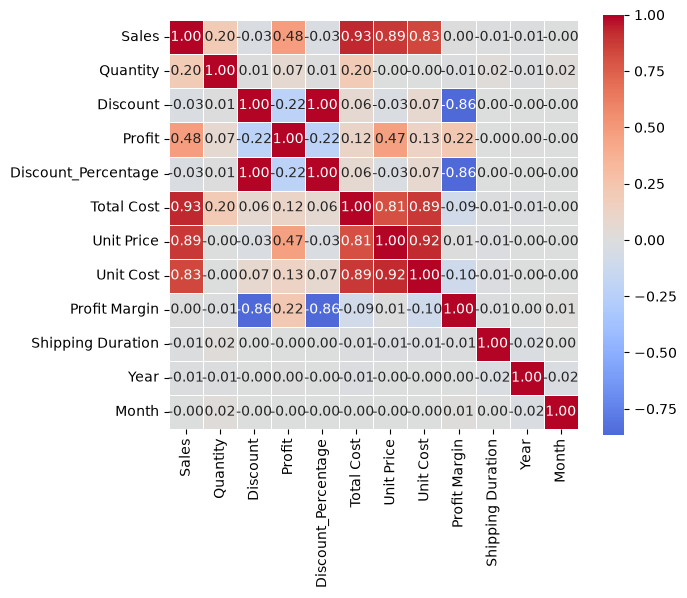

In [69]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
plt.tight_layout()
plt.show()

>**Key Insight :-** <br>
>There is a weak correlation between discount and profit margin; therefore, offering discounts cannot be relied upon to increase overall profits.
>There is a strong correlation between total cost and sales.
><br>
><br>

### **KPIs Summary :-**

In [70]:
print("--------- KPIs ---------\n")
kpis ={
'Total_Sales' : df['Sales'].sum().round(2),
'Total_Costs' : df['Total Cost'].sum().round(2),
'N.Cities' : df['City'].nunique(),
'N.States' : df['State'].nunique(),
'Total_profit' : df["Profit"].sum().round(2),
'Total_orders' : df["Order ID"].nunique(),
'AVG_Discount'  : df["Discount_Percentage"].mean().round(2) ,
'Total_Customers': df["Customer ID"].nunique(),
'Total_Products' : df["Product ID"].nunique(),
'N.Returned_Orders' : df.loc[df["Returned"].eq("Yes"), "Order ID"].nunique()
}
for k ,v in kpis.items():
    print(f'{k}:{v}')



--------- KPIs ---------

Total_Sales:2297200.86
Total_Costs:2010803.84
N.Cities:531
N.States:49
Total_profit:286397.02
Total_orders:5009
AVG_Discount:15.62
Total_Customers:793
Total_Products:1862
N.Returned_Orders:296


## **Data Visulization :-** 

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">14. Which category leads in total sales vs. total profit? </h1>

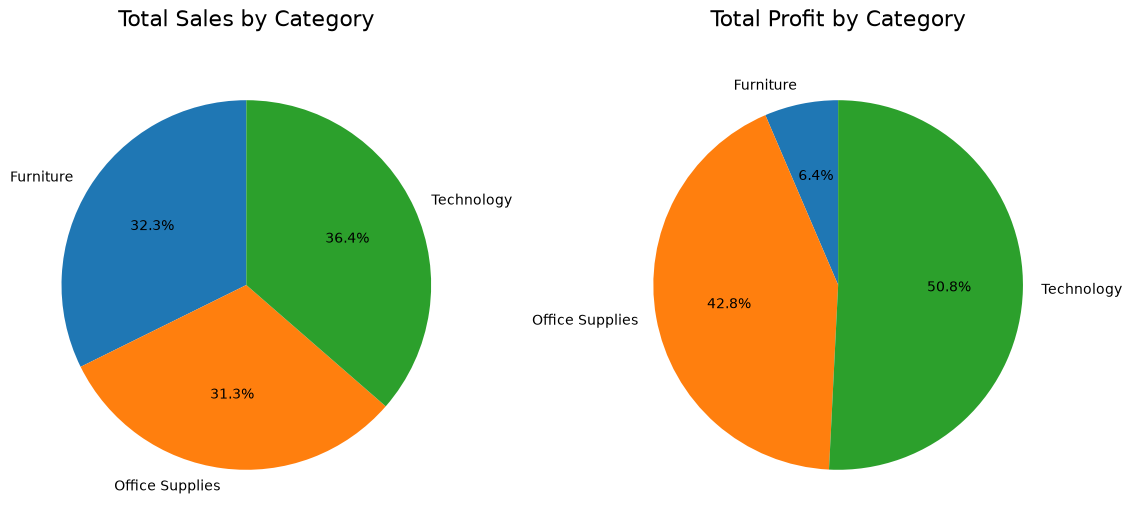

In [71]:
category_sales= df.groupby('Category')['Sales'].sum()
category_profit=df.groupby('Category')['Profit'].sum()

fig, ax = plt.subplots(1,2,figsize=(14,6))
ax[0].pie(
    category_sales, 
    labels=category_sales.index, 
    autopct='%1.1f%%',
    startangle=90)

ax[1].pie(    
    category_profit, 
    labels=category_profit.index, 
    autopct='%1.1f%%',
    startangle=90)

ax[0].set_title('Total Sales by Category', fontsize=16, pad=20)
ax[1].set_title('Total Profit by Category', fontsize=16, pad=20)
plt.show()

>**Key Insight :-** <br>
>**Technology is the Highest Revenue & Profit Driver:** Technology leads in total Sales (836,154.03) and Profit (145,454.95), achieving the highest Profit Margin (15.61%).<br>
> **Furniture is the Lowest Profit Contributor:** Although Furniture generates high revenue (741,999), it contributes the lowest profit (18,451) and a weak Profit Margin of 3.88%, mainly driven by excessively high total product costs(723,548.52)
><br>
><br>

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">15.Which customer segment drives the highest sales in each category? </h1>

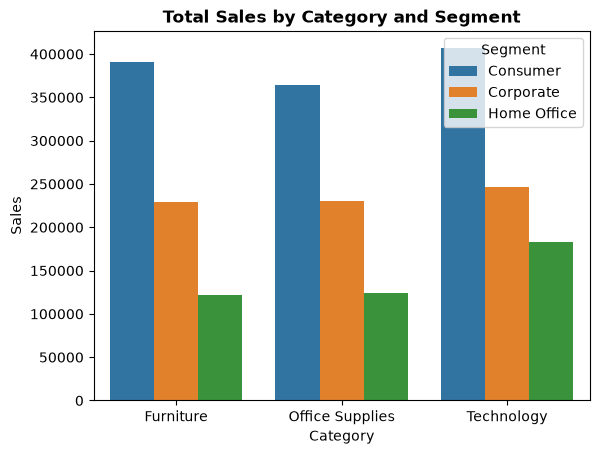

In [72]:
sns.barplot(data =df,x='Category',y='Sales',hue='Segment',estimator='sum',errorbar=None)
plt.title('Total Sales by Category and Segment',fontweight='bold')
plt.show()

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;"> 16.What are the top 5 best-selling and top 5 least profitable sub-categories? </h1>

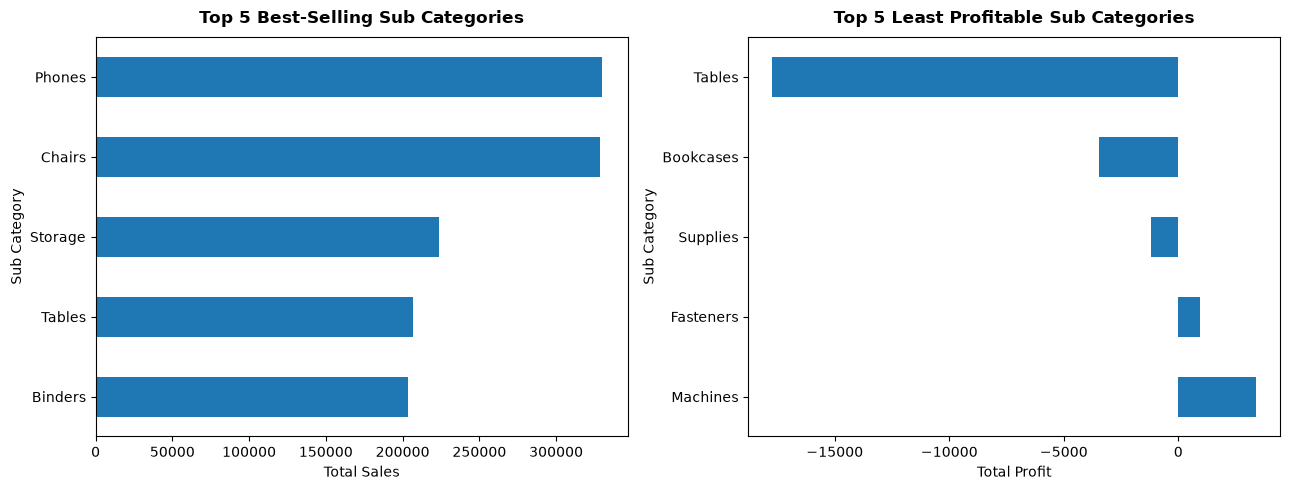

In [73]:
#the top 5 best-selling sub-categories
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top5_sales = df.groupby('Sub Category')['Sales'].sum().nlargest(5).sort_values(ascending=True)
top5_sales.plot(kind='barh', ax=axes[0])

axes[0].set_title('Top 5 Best-Selling Sub Categories', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Total Sales')

##the top 5 least profitable sub-categories
least5_profit = df.groupby('Sub Category')['Profit'].sum().nsmallest(5).sort_values(ascending=False)
least5_profit.plot(kind='barh', ax=axes[1])

axes[1].set_title('Top 5 Least Profitable Sub Categories', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Total Profit')

plt.tight_layout()
plt.show()

>**Key Insight :-** <br>
>Highest Revenue: **Phones and Chairs** lead in total sales, reaching over 300,000 <br>
>Lowest Profit Contributor: **Tables** records the highest loss, dropping below -15,000.<br>
><br>
><br>

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">17. Which region generated the highest total sales? </h1>

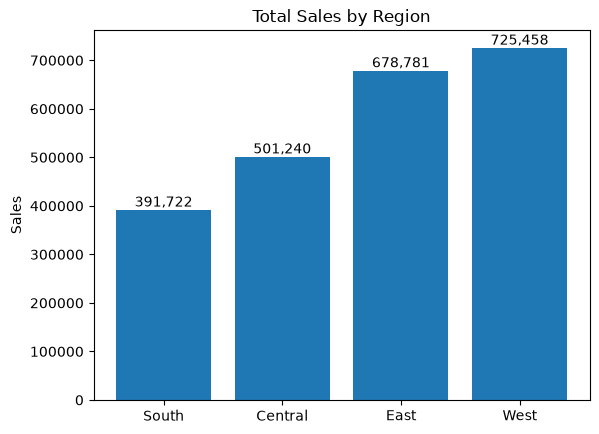

In [74]:
region_sales = (df.groupby('Region')['Sales'].sum().sort_values()).reset_index(name='Total_Sales')
bar_chart1 = plt.bar(region_sales['Region'],region_sales['Total_Sales'])


plt.title('Total Sales by Region')
plt.ylabel('Sales')
plt.ylabel('Sales')


for bar in bar_chart1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )
    
plt.show()


>**Key Insight :-** <br>
>**The West** region has the highest total sales
><br>
><br>

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">18. What are the top 10 most profitable states? </h1>

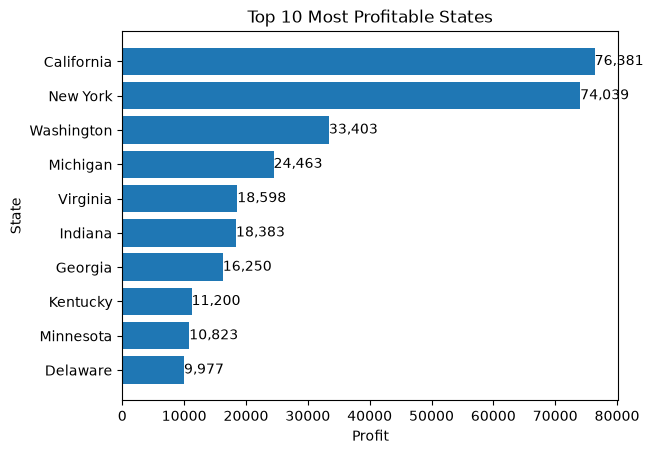

In [75]:

top_states = (df.groupby('State')['Profit'].sum().nlargest(10).sort_values().reset_index(name='Total_Profit'))
bar_chart2= plt.barh(top_states['State'],top_states['Total_Profit'])

for bar in bar_chart2:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va='center',
        ha='left'
    )
plt.title('Top 10 Most Profitable States')
plt.xlabel('Profit')
plt.ylabel('State')
plt.show()

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">19. Which category has the highest number of returned orders?</h1>

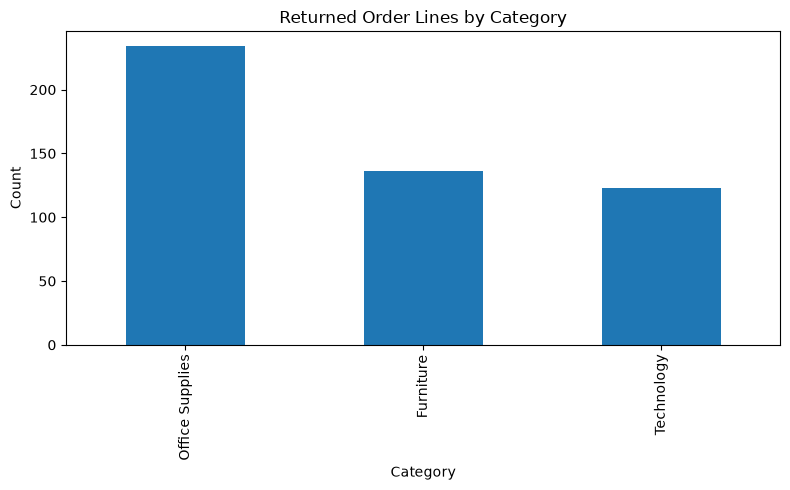

In [76]:
returned_orders = df[df['Returned'] == 'Yes']
return_by_cat = returned_orders.groupby('Category', observed=True)['Order ID'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
return_by_cat.plot(kind='bar', ax=ax)
ax.set_title('Returned Order Lines by Category')
ax.set_ylabel('Count')
plt.tight_layout()

plt.show()

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">20. How have total sales trended over time? </h1>

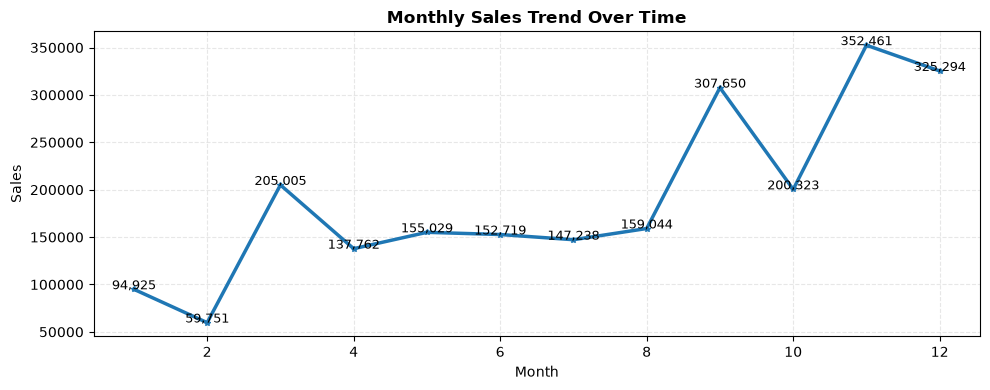

In [77]:
monthly_sales =(df.groupby('Month')['Sales'].sum().reset_index(name='Total_Sales'))

plt.figure(figsize=(10, 4))
plt.plot(monthly_sales['Month'], monthly_sales['Total_Sales'], linewidth=2.5, marker='*', markersize=4)

for x, y in zip(monthly_sales['Month'], monthly_sales['Total_Sales']):
    plt.annotate(
        f'{y:,.0f}',
        (x, y),
        ha='center',
        fontsize=9
    )

plt.title('Monthly Sales Trend Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

>**Key Insight :-** <br>
>Sales consistently peak before and during January of every year, showing a clear seasonal pattern
><br>
><br>

> <h1 style="color: #ff1717; font-size: 23px; margin: 0;">21.What is the Most Popular Ship Mode? </h1>

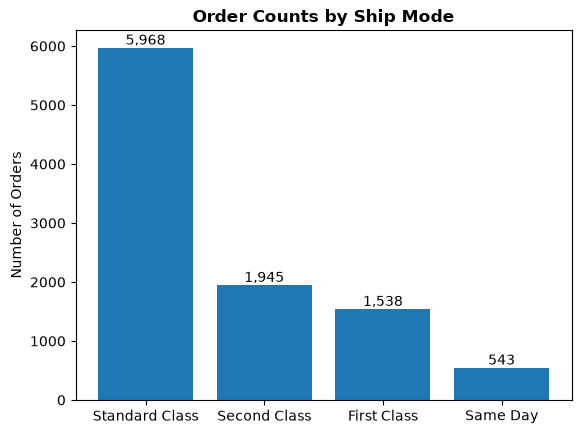

In [78]:
ShipMode_Sales = (df['Ship Mode'].value_counts().reset_index(name = 'ship_counts'))
bar_chart3= plt.bar(ShipMode_Sales['Ship Mode'],ShipMode_Sales['ship_counts'])


for bar in bar_chart3:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )
    
plt.title('Order Counts by Ship Mode', fontweight='bold')
plt.ylabel('Number of Orders')

plt.show()

>**Key Insight :-** <br>
>Although **Same Day** delivery ensures orders are delivered on the exact same day, **Standard Class** remains the most *frequently used shipping mode*
><br>
><br>

In [79]:
#Export The Output to CSV
from pathlib import Path
import os

OUTPUT = Path('superstore')
OUTPUT.mkdir(exist_ok=True)

df.to_csv('superstore/superstore_miniproject.csv')
logging.info('Analysis Completed')